# ADK で画像ファイルを扱う方法

このノートブックでは、AI エージェントが生成した画像をユーザーインターフェースに表示する方法、および、ユーザーインターフェースから画像ファイルを入力する方法を学びます。

## 事前準備

**[IFH-01]**

ADK と Gemini API の利用に必要なパッケージをインストールします。

ADK は開発の速度が速く、後方互換性のない機能変更が行われることがあります。ここでは、安全のために動作確認ができたバーションを指定してインストールしています。

**最後に `RESTART SESSION` ボタンが表示された場合は、これをクリックしてセッションを再起動してください。**

**注意**: `ERROR: pip's dependency resolver does not currently take into account...` のようなエラーメッセージが表示される場合がありますが、これは無視して構いません。

In [ ]:
%pip install --upgrade --user \
    google-adk==2.8.0 \
    google-cloud-aiplatform==2.0.1 \
    google-genai==2.20.0 \
    vl-convert-python==1.9.0.post1 \
    pillow==12.3.0

**[IFH-02]**

インストールされたパッケージのバージョンを確認します。

In [1]:
!pip list | grep -E "(google-adk|google-genai|google-cloud-aiplatform|vl-convert-python|pillow)"

google-adk                            2.8.0
google-cloud-aiplatform               2.0.1
google-genai                          2.20.0
pillow                                12.3.0
vl-convert-python                     1.9.0.post1


下記の内容が出力されたことを確認してください。

```
google-adk                               2.8.0
google-cloud-aiplatform                  2.0.1
google-genai                             2.20.0
pillow                                   12.3.0
vl-convert-python                        1.9.0.post1
```

## ユーザー認証

**[IFH-03]**

変数 `PROJECT_ID` に事前に準備したプロジェクトのプロジェクト ID を指定してください。

**注意**: プロジェクトを作成したユーザーアカウントと Colab を使用中のユーザーアカウントが一致している必要があります。


In [ ]:
###
PROJECT_ID = 'Project ID を入力'
###

if (not PROJECT_ID) or PROJECT_ID == 'Project ID を入力':
    print('Gemini API を使用する Google Cloud Project の Project ID を入力してください。')
else:
    print(f'変数 PROJECT_ID を設定しました。')
    print(f'PROJECT_ID = {PROJECT_ID}')

**[IFH-04]**

Google Cloud のプロジェクトを使用するためのユーザー認証を行います。

ポップアップ画面の指示に従って、認証処理を行ってください。

許可する操作を選択するチェックボックスが表示された場合は、すべてにチェックを入れてください。

In [3]:
from google.colab import auth
auth.authenticate_user(project_id=PROJECT_ID)

## 初期設定

**[IFH-05]**

この後の作業に必要なモジュールをインポートして、LlmAgent オブジェクトが参照する環境変数を設定します。あわせて、アーティファクトを保存するクラウドストレージのバケットを作成します。

In [4]:
import base64, copy, json, io, os, re, urllib, uuid
import vl_convert as vlc
from PIL import Image
from IPython.display import Markdown, display
import agentplatform
from agentplatform.frameworks import AdkApp
from google import genai
from google.genai.types import (
    Content, GenerateContentConfig,
    ImageConfig, Part, SafetySetting,
)
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.plugins.save_files_as_artifacts_plugin import SaveFilesAsArtifactsPlugin
from google.adk.tools import load_artifacts
from google.adk.tools import google_search
from google.adk.tools import ToolContext
from google.adk.tools.agent_tool import AgentTool
from google.genai.types import Part

agentplatform.init(project=PROJECT_ID, location='us-central1')
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l us-central1 gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_artifacts/


**[IFH-06]**

AdkApp オブジェクトとの会話を行う簡易的なアプリケーションのクラス ChatClient を定義します。

In [29]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

## グラフ画像を作成するツール関数

**[IFH-07]**

Vega-Lite の JSON テキストを受け取って、グラフ画像を作成・保存する関数を定義します。

In [30]:
async def save_vega_chart_artifact(
    vl_spec_json: str, tool_context: ToolContext,
) -> str:
    """
    Vega-Lite の JSON 仕様を受け取り、PNG 画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-Lite の JSON 仕様文字列

    Returns:
        str: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """

    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if 'config' not in spec:
            spec['config'] = {}
        spec['config']['font'] = 'Noto Sans CJK JP'
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=90)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        filename = f'{uuid.uuid4()}.png'
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

**[IFH-08]**

ツール関数 `save_vega_chart_artifact` を利用して、グラフ画像を作成する LlmAgent オブジェクト `chart_agent` を定義します。

`AgentTool(chart_agent)` でツール関数に変換すると、グラフ画像を作成するツール関数として利用できます。

In [31]:
instruction='''
あなたはデータ可視化の専門家です。ユーザーからの依頼に応じて、次の手順でグラフ画像を作成します。
1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用する。
2. 生成した JSON 仕様を save_vega_chart_artifact で PNG 画像として保存する。
3. 作成したグラフのタイトルと保存したファイル名を次のフォーマットで出力する。
```
- title: <グラフのタイトル>
- filename: <ファイル名>
```
'''

chart_agent = LlmAgent(
    name='chart_agent',
    model='gemini-3.1-flash-lite',
    description='与えられたデータからグラフを作成する AI エージェント',
    instruction=instruction,
    tools=[save_vega_chart_artifact],
)

## ファイル名と画像ファイルデータを相互変換するコールバック関数

**[IFH-09]**

マークダウンテキスト内の `![<画像の説明>](<ファイル名>)`という部分を対応するアーティファクトを用いて、`![<画像の説明#ファイル名>](<base64 文字列>)` に置換する関数を定義します。

In [6]:
async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=300,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\((.*?)\)'

    # find filenames in the markdown text.
    matches = list(re.finditer(pattern, markdown_text, flags=re.MULTILINE))
    if not matches:
        return markdown_text
    unique_filenames = {match.group(2) for match in matches}

    image_map = {}
    for filename in unique_filenames:
        print(f'## Converting `{filename}` into base64 string.', flush=True)
        image_artifact = await callback_context.load_artifact(filename=filename)
        image_bytes = image_artifact.inline_data.data

        # Resize and convert to jpeg image.
        with Image.open(io.BytesIO(image_bytes)) as img:
            if img.mode in ('RGBA', 'P'):
                img = img.convert('RGB')
            if max_width and img.width > max_width:
                ratio = max_width / img.width
                new_height = int(img.height * ratio)
                img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

            output_buffer = io.BytesIO()
            img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
            jpeg_data = output_buffer.getvalue()

        # Create filename to base64 string map.
        b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
        image_map[filename] = f'data:image/jpeg;base64,{b64_encoded}'

    def replacer(match):
        alt_text, filename = match.group(1), match.group(2)
        return f'![{alt_text}#{filename}]({image_map[filename]})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[IFH-10]**

関数 `replace_filename_with_base64` で大規模言語モデルの応答メッセージに含まれるファイル名を対応するアーティファクトの base64 文字列に置き換えて、インライン画像を用意するコールバック関数を定義します。

In [38]:
async def callback_load_images(
    callback_context, llm_response,
):
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=500,
            callback_context=callback_context,
        )

    return None

**[IFH-11]**

マークダウンテキスト内の `![<画像の説明#ファイル名>](<base64 文字列>)` という部分を `![<画像の説明>](<ファイル名>)` に置換する関数を定義します。

In [39]:
def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            filename = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        print(f'## Replacing base64 string with `{filename}`', flush=True)
        return f'![{clean_alt_text}]({filename})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[IFH-12]**

関数 `replace_base64_with_filename` で大規模言語モデルへの入力メッセージに含まれるインライン画像をファイル名に置き換えるコールバック関数を定義します。

In [40]:
async def callback_remove_base64(
    callback_context, llm_request,
):
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

## データ分析 AI エージェントの作成

**[IFH-13]**

用意したツール関数とコールバック関数を用いて、データの収集と可視化を行う AI エージェントを作成します。

In [49]:
instruction = '''
あなたはデータ分析の専門家です。ユーザーの指示に従ってデータを収集・分析します。
重要なポイントはグラフでわかりやすく可視化してください。

# 情報収集
- 必要な際は google_search で情報を収集します。
- レポート内に検索先の情報ソースを明示します。

# グラフ生成・表示の方法
グラフを生成・表示する際は、次のステップに従います。
  1. chart_agent にグラフの作成を依頼します。ツールは、生成したグラフ画像のファイル名を返します。ファイル名の形式は `<UUID>.png` です。
  2. 応答文に以下の形式の行を挿入して画像を表示します。フロントエンドによって、この部分に実際の画像が描画されます。前後の空行は必ず必要です。
```markdown

![<画像の説明>](<ファイル名>)

```
'''

data_analyst_agent = LlmAgent(
    name='data_analyst_agent',
    model='gemini-3.8-flash',
    description='データを収集して可視化レポートを作成するAIエージェント',
    instruction=instruction,
    tools=[
        AgentTool(chart_agent),
        google_search,
    ],
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

data_analyst_app = AdkApp(
    agent=data_analyst_agent,
    app_name='data_analyst_app',
    artifact_service_builder=artifact_builder,
)

**[IFH-14]**

作成した AI エージェントでグラフを含むレポートを作成します。

## Converting `5c4a8381-cb34-478b-8907-bc581cbca31e.png` into base64 string.


総務省統計局が公表している最新の公的推計データ（2024年10月1日現在）に基づき、都道府県別の総人口トップ5をまとめました。

---

### 都道府県別 総人口トップ5（2024年10月1日現在）

| 順位 | 都道府県 | 総人口（万人） | 全国比率 | 前年比増減率 |
| :---: | :---: | :---: | :---: | :---: |
| **1位** | **東京都** | 1,417.8 万人 | 11.5% | +0.65% |
| **2位** | **神奈川県** | 922.5 万人 | 7.5% | -0.11% |
| **3位** | **大阪府** | 875.7 万人 | 7.1% | -0.27% |
| **4位** | **愛知県** | 746.0 万人 | 6.0% | -0.27% |
| **5位** | **埼玉県** | 733.2 万人 | 5.9% | -0.11% |

※全国総人口：1億2,380万2千人

---

### 人口推移・構成の可視化

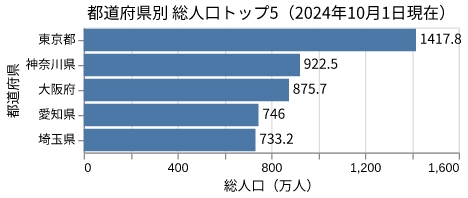

---

### 主な分析ポイント

1. **東京一極集中の傾向**
   - 東京都は唯一 **1,400万人** を超えており、2位の神奈川県（約922万人）に500万人近くの差をつけています。
   - トップ5のうち、前年比で人口が増加したのは**東京都のみ（+0.65%）**であり、首都圏への人口流入・集中のトレンドが続いています。
2. **大都市圏への偏在**
   - トップ5（東京都、神奈川県、大阪府、愛知県、埼玉県）の人口を合算すると約**4,695万人**となり、**日本全体の総人口の約38%**をこれら5都府県のみで占めています。

---

**【情報ソース】**
- 総務省統計局：[人口推計（2024年（令和6年）10月1日現在）‐全国：年齢（各歳）、男女別人口 ・ 都道府県：男女別人口及び人口性比‐](https://www.stat.go.jp/data/jinsui/2024np/index.html)

In [50]:
chat_client = ChatClient(data_analyst_app)

query = '''
入手可能な最新データを検索して、都道府県別の総人口トップ5をグラフ表示。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

## 画像修正 AI エージェントの作成

**[IFH-15]**

Gemini API の画像生成モデルを用いて、画像を修正する汎用の関数を定義します。

In [10]:
def generate_image(system_instruction, contents):
    client = genai.Client(vertexai=True)
    model = 'gemini-3.1-flash-lite-image'

    config = GenerateContentConfig(
        system_instruction=system_instruction,
        response_modalities=['IMAGE'],
        safety_settings=[
            SafetySetting(category='HARM_CATEGORY_HATE_SPEECH', threshold='OFF'),
            SafetySetting(category='HARM_CATEGORY_DANGEROUS_CONTENT', threshold='OFF'),
            SafetySetting(category='HARM_CATEGORY_SEXUALLY_EXPLICIT', threshold='OFF'),
            SafetySetting(category='HARM_CATEGORY_HARASSMENT', threshold='OFF'),
        ],
        image_config=ImageConfig(
            output_mime_type='image/png',
        ),
    )

    print(f'## Generating an image using {model}.')
    response = client.models.generate_content(
        model=model,
        contents=contents,
        config=config,
    )
    for part in response.candidates[0].content.parts:
        if part.inline_data:
            return part.inline_data

    print(f'## Failed to generate an image.')
    return None

**[IFH-16]**

関数 `generate_image` を用いて、修正画像を生成するツール関数を定義します。

In [11]:
async def modify_image_tool(
    filename: str, prompt: str, tool_context: ToolContext,
) -> str:
    """
    ユーザーの指示に基づいて、入力画像を修正する関数

    Args:
        filename (str) : 入力画像のファイル名
        prompt (str): 修正指示

    Returns:
        str: 修正後の画像のファイル名
    """

    image_artifact = await tool_context.load_artifact(filename=filename)
    inline_data = image_artifact.inline_data

    system_instruction = 'ユーザーの指示に従って画像を修正'
    parts = [
        Part.from_bytes(
            data=inline_data.data,
            mime_type=inline_data.mime_type,
        ),
        Part.from_text(text=prompt),
    ]
    contents = [Content(parts=parts, role='user')]
    inline_data = generate_image(system_instruction, contents)
    if not inline_data:
        return None

    image_artifact = Part.from_bytes(
        data=inline_data.data,
        mime_type=inline_data.mime_type,
    )
    new_filename = f'{uuid.uuid4().hex}.png'
    await tool_context.save_artifact(
        filename=new_filename,
        artifact=image_artifact,
    )

    return new_filename

**[IFH-17]**

ツール関数 `modify_image_tool` を用いて、画像を修正する AI エージェントを作成します。

先ほど用意した、画像ファイルを表示するコールバック関数も利用します。

In [12]:
image_edit_agent = LlmAgent(
    name='image_edit_agent',
    model='gemini-3.1-flash-lite',
    instruction='''
あなたは画像編集のスペシャリストです。
- ユーザーが入力した画像を指示に従って修正します。
- modify_image_tool で修正画像を生成します。ツールは、生成画像のファイル名を返します。ファイル名の形式は `<UUID>.png` です。

# 画像を表示する方法
画像を表示する際は、応答文に以下の形式の行を挿入して画像を表示します。フロントエンドによって、この部分に実際の画像が描画されます。前後の空行は必ず必要です。
```markdown

![<画像の説明>](<ファイル名>)

```
''',
    tools=[modify_image_tool],
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

image_edit_app = AdkApp(
    agent=image_edit_agent,
    app_name='image_edit_app',
    artifact_service_builder=artifact_builder,
    plugins=[SaveFilesAsArtifactsPlugin()],
)

**[IFH-18]**

テストに使用する画像ファイルをダウンロードします。

テレビでサッカーを観戦する家族のイラスト画像です。

In [14]:
!curl -OL https://raw.githubusercontent.com/enakai00/colab_adk_book/refs/heads/main/Chapter04/example_image.png

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  526k  100  526k    0     0  1828k      0 --:--:-- --:--:-- --:--:-- 1833k


**[IFH-19]**

画像ファイルを base64 ストリングに変換する関数を用意して、画像データを含むリクエストを送信します。

## Generating an image using gemini-3.1-flash-lite-image.
## Converting `ae6aa47e14914886870966b66a61ff85.png` into base64 string.


ご指示通り、テレビ画面をテニスの試合に変更しました。

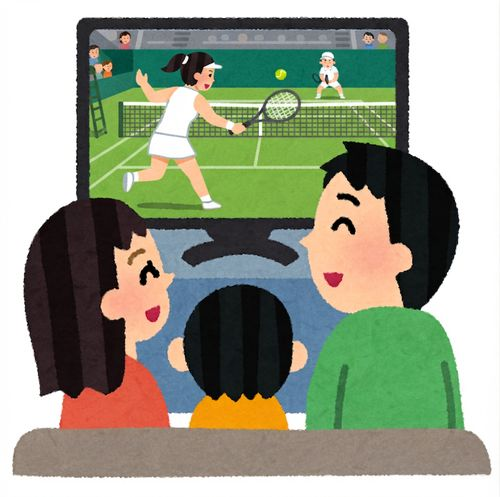

In [26]:
def get_image_data(file_path: str):
    with open(file_path, 'rb') as f:
        image_bytes = f.read()
    return base64.b64encode(image_bytes).decode('utf-8')

chat_client = ChatClient(image_edit_app)

image_base64 = get_image_data('example_image.png')
message_input = {
        'role': 'user',
        'parts': [
            {'text': 'テレビの画面をテニスに変更'},
            {
                'inline_data': {
                    'mime_type': 'image/png',
                    'data': image_base64
                }
            }
        ]
}

response = await chat_client.async_stream_query(message_input)
display(Markdown(response))

**[IFH-20]**

元の画像もアーティファクトに保存されているので、AI エージェントに依頼すると表示できます。

## Replacing base64 string with `ae6aa47e14914886870966b66a61ff85.png`
## Converting `artifact_e-ec515796-01bd-43ee-a457-ca0a9e8298be_1` into base64 string.


元の画像は以下の通りです。

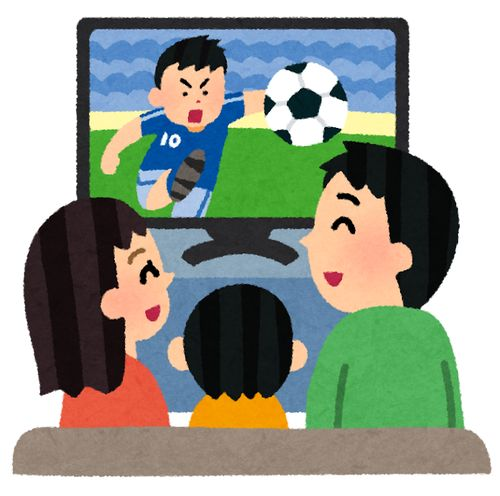

In [27]:
query = '''
元の画像を表示
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))